### Default simulation parameters for the Glasma and the Wong solvers

In [ ]:
import numpy as np

# hbar * c [GeV * fm]
hbarc = 0.197326 

# Simulation box 
L = 10      
N = 512  
# N = 1024  
tau_sim = 1.5
# tau_sim = 1
DTS = 8     

# Glasma fields
su_group = 'su3'

Qs = 2        
ns = 50    
factor = 0.8        
g2mu = Qs / factor     
g = np.pi * np.sqrt(1 / np.log(Qs / 0.2))          		
mu = g2mu / g**2          	
ir = 0.1 * g**2 * mu  
 
uv = 10.0           

In [1]:
import numpy as np

# hbar * c [GeV * fm]
hbarc = 0.197326 

# Simulation box 
L = 10.0
N = 512
tau_sim = 1.0
DTS = 8

# Glasma fields
su_group = 'su3'
uv = 10.0
ir = 0.2
g2mu = 2.0

# Derived parameters
a = L/N
E0 = N / L * hbarc
DT = 1.0 / DTS
maxt = int(tau_sim / a * DTS)
nplus = maxt//DTS

g = 2         		
mu = g2mu / g**2

ns = 1      

nevents = 1
# quark = 'jet' # 'jet' or 'static'            
quark = 'static'

# coulomb_gauge_mode = 'every_step' # 'none' or 'every_step' or 'initial'
coulomb_gauge_mode = 'initial'
# coulomb_gauge_mode = 'none'
alpha = 5

# Condition 1: 2*pi/L < m  (m ir regulator)
cond1_lhs = 2 * np.pi / L * hbarc
cond1 = cond1_lhs < ir
print(f"2π/L = {cond1_lhs:.4f} < m = {ir} {'passed' if cond1 else 'failed'}")

# Condition 2: m / g2mu < 1  (dense glasma)
cond2_lhs = ir / g2mu
cond2 = cond2_lhs < 1
print(f"m/g2mu = {cond2_lhs:.4f} < 1 {'passed' if cond2 else 'failed'}")

# Condition 3: g2mu * a < 1  (fine lattice)
cond3_lhs = g2mu * a / hbarc
cond3 = cond3_lhs < 1
print(f"g2mua = {cond3_lhs:.4f} < 1 {'passed' if cond3 else 'failed'}")

print(f"g2muL = {g2mu * L / hbarc :.4f}")

2π/L = 0.1240 < m = 0.2 passed
m/g2mu = 0.1000 < 1 passed
g2mua = 0.1980 < 1 passed
g2muL = 101.3551


In [2]:
# Wong solver 
quark = 'any'
mass = 1   
tau_form = 0   
pT = 0   
ntp = 10**5  
# nevents = 10
# nevents = 2    
boundary = 'periodic'       

# Store relevant parameters in a dictionary
p = {
    'QUARK': quark,
    'MASS': mass, 
    'TFORM': tau_form,
    'TSIM': tau_sim,
    # 'QS': Qs,
    'G2MU': g2mu,            
    'NEVENTS': nevents,
    'NTP': ntp,   
    'PT': pT,
    }

### Set environment variables

In [3]:
import os
os.environ["MY_NUMBA_TARGET"] = "cuda"
os.environ["PRECISION"] = "double"
os.environ["GAUGE_GROUP"] = su_group

# Import relevant modules
import sys
sys.path.append('../..')

# Glasma modules
import curraun.core as core
import curraun.mv as mv
import curraun.initial as initial
initial.DEBUG = False

import curraun.su as su
from curraun.numba_target import use_cuda
if use_cuda:
    from numba import cuda

# Wong modules
from curraun import wong
wong.BOUNDARY = boundary
wong.CUB_MOM = False
from curraun.wong import init_mom_toy, init_pos

Using CUDA
Using SU(3)
Using double precision
Using double precision


#### Initialization of color charge

In [4]:
from scipy.stats import unitary_group

# gell-mann matrices

gm = [
    [[0, 1, 0], [1, 0, 0], [0, 0, 0]],
    [[0, -1j, 0], [1j, 0, 0], [0, 0, 0]],
    [[1, 0, 0], [0, -1, 0], [0, 0, 0]],
    [[0, 0, 1], [0, 0, 0], [1, 0, 0]],
    [[0, 0, -1j], [0, 0, 0], [1j, 0, 0]],
    [[0, 0, 0], [0, 0, 1], [0, 1, 0]],
    [[0, 0, 0], [0, 0, -1j], [0, 1j, 0]],
    [[1 / np.sqrt(3), 0, 0], [0, 1 / np.sqrt(3), 0], [0, 0, -2 / np.sqrt(3)]]
]

T = np.array(gm) / 2.0

def init_charge(q2):
    """
        Step 1: specific random color vector
    """
    # Here q_3=0
    q0 = [np.sqrt(q2), 0., 0., 0., 0., 0., 0., 0.]
    Q0 = np.einsum('ijk,i', T, q0)

    """
        Step 2: create a random SU(3) matrix to rotate Q.
    """
    
    V = unitary_group.rvs(3)
    detV = np.linalg.det(V)
    U = V / detV ** (1 / 3)
    Ud = np.conj(U).T

    Q = np.einsum('ab,bc,cd', U, Q0, Ud)

    """
        Step 3: Project onto color components
    """

    q = 2 * np.einsum('ijk,kj', T, Q)
    return np.real(q)

- - - 
# Dependence of momentum broadening on the quadratic Casimir

In [5]:
import pickle
from tqdm import tqdm

# Simulation routine
def simulate(p, ev): 
    q2 = p["q2"]

    output = {}
    output["parameters"] = p.copy()

    tau_form = p["TFORM"]
    tau_sim = p["TSIM"] + tau_form 
    mass = p["MASS"]
    pT = p["PT"]

    # Derived parameters
    a = L / N
    E0 = N / L * hbarc
    DT = 1.0 / DTS
    formt = int(tau_form / a * DTS)
    maxt = int(tau_sim / a * DTS)

    # Initialize Glasma fields
    s = core.Simulation(N, DT, g)
    va = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=ns)
    vb = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=ns)
    initial.init(s, va, vb)

    # Initialize the Wong solver
    wong_solver = wong.WongSolver(s, ntp)
    x0s, p0s, q0s = np.zeros((ntp, 3)), np.zeros((ntp, 5)), np.zeros((ntp, su.ALGEBRA_ELEMENTS))
    masses = mass / E0 * np.ones(ntp)

    for i in range(ntp):
        x0, p0, q0 = init_pos(s.n), init_mom_toy('pT', pT / E0), init_charge(q2)
        x0s[i, :], p0s[i, :], q0s[i, :] = x0, p0, q0

    wong_solver.initialize(x0s, p0s, q0s, masses)

    psq = np.zeros((maxt-formt, 4)) 

    with tqdm(total=maxt) as pbar:
        for t in range(maxt):
            # Evolve Glasma fields
            core.evolve_leapfrog(s)

            # Solve Wong's equations
            if t>=formt:  
                psq_wong = wong_solver.p_sq_mean
                psq[t-formt, :] = psq_wong * E0**2

                wong_solver.evolve()
                wong_solver.compute_mom_broad()

            pbar.set_description("Event " + str(ev+1))
            pbar.update(1)

    formt, maxt = int(tau_form / L * N * DTS), int(tau_sim / L * N * DTS)
    tau = np.linspace(0, tau_sim, maxt-formt)

    output["psq"], output["tau"] = psq, tau

    return output

In [ ]:
# q2s = [4/3, 4.0]
# q2s = np.linspace(0, 6, 19)
q2s = np.linspace(1, 4, 10)

# quarks = ['infmass', 'beauty', 'charm']
# quark_masses = [10**6, 4.18, 1.27]

# quarks = ['pxinf', 'm_2_px_10', 'm_0.1_px_2']
# quark_masses = [0.1, 2, 0.1]
# pTs = [1000, 10, 2]

quarks = ['pxinf', 'px_5g2mu', 'px_g2mu']
quark_masses = [0.1, 0.1, 0.1]
pTs = [1000, 10, 2]

# quarks = ['beauty', 'charm']
# quark_masses = [4.18, 1.27]

# quarks = ['infmass']
# quark_masses = [10**6]

psq, tau = {}, {}
for iq, quark in enumerate(quarks):
    print(quarks[iq].capitalize() + " quark")
    p['QUARK'], p['MASS'], p['PT'] = quark, quark_masses[iq], pTs[iq]
    # transverse mass
    # mT = np.sqrt(p["MASS"]**2+p["PT"]**2)   
    # p['TFORM'] = 1/(2*mT)*hbarc
    p['TFORM'] = 0
    # if quark=='infmass':
        # p['TFORM'] = 0.

    psq[quark], tau[quark] = {}, {}

    for q2 in q2s:
        p["q2"] =  q2
        print("q2 =", p["q2"])

        psqs = []

        for ev in range(nevents):
            output = simulate(p, ev)
            psqs.append(output["psq"])

        psq[quark][str(q2)] = np.mean(psqs, axis=0)

    tau[quark] = output["tau"]
    

output = {}
output["psq"], output["tau"] = psq, tau
output["quarks"], output["q2s"] = quarks, q2s
output["masses"], output["pTs"] = quark_masses, pTs
output["parameters"] = p.copy()

filename = 'jet_mom_broad_q2_dep_g2mu_2.pickle'
with open(filename, 'wb') as handle:
    pickle.dump(output, handle)

Pxinf quark
q2 = 1.0


Event 1: 100%|██████████| 409/409 [01:52<00:00,  3.63it/s]


q2 = 1.3333333333333333


Event 1: 100%|██████████| 409/409 [01:43<00:00,  3.95it/s]


q2 = 1.6666666666666665


...

Event 1: 100%|██████████| 409/409 [01:42<00:00,  3.99it/s]


q2 = 3.6666666666666665


Event 1: 100%|██████████| 409/409 [01:43<00:00,  3.97it/s]


q2 = 4.0


Event 1: 100%|██████████| 409/409 [01:49<00:00,  3.74it/s]


- - -

In [1]:
filename = 'jet_mom_broad_q2_dep_g2mu_2.pickle'
with open(filename, 'rb') as handle:
    results = pickle.load(handle)

q2s   = results["q2s"]
quarks = results["quarks"]
# g2mu = results["parameters"]["G2MU"]
g2mu = 2

with open('/n/work00/davrames/curraun/notebooks/results/jet_mom_broad_casimir_scaling_finer_lattice.pickle', 'rb') as f:
    results_cs = pickle.load(f)

NameError: name 'pickle' is not defined

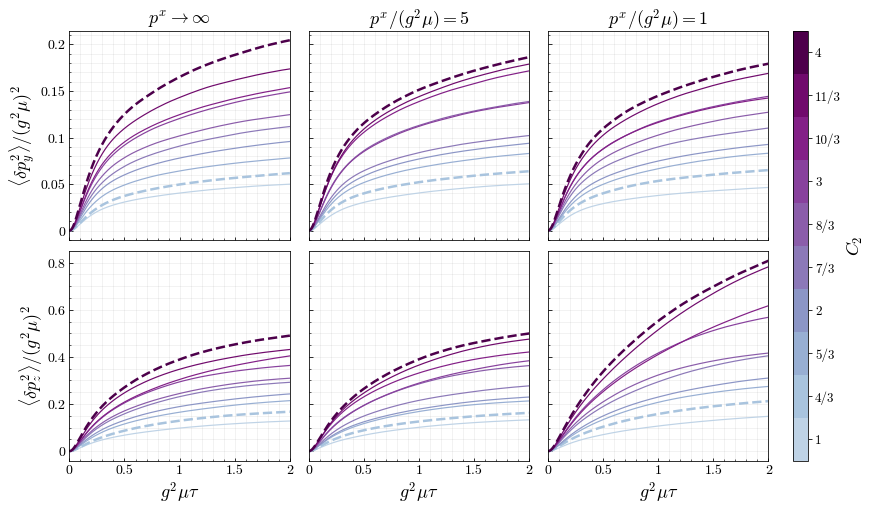

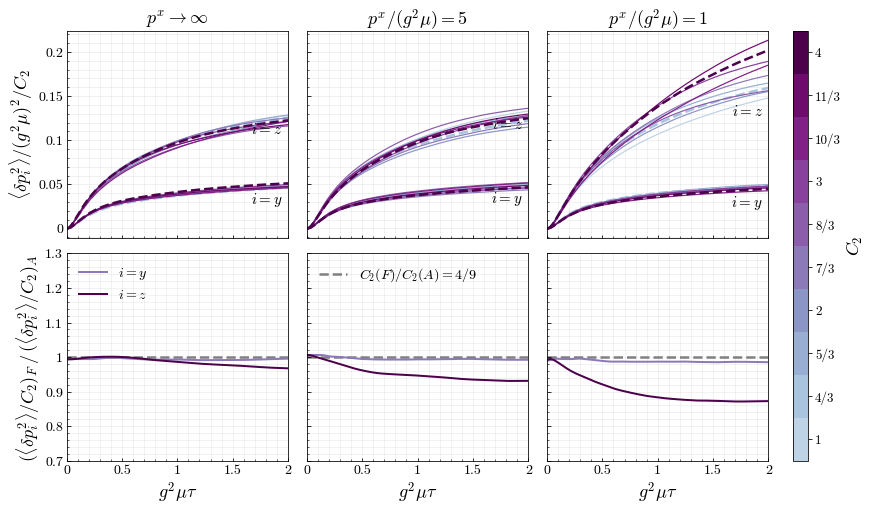

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as mticker
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.lines import Line2D
from fractions import Fraction

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['axes.formatter.use_mathtext'] = True

# Discrete colormap — skip first 3 bright colors of BuPu
n = len(q2s)
skip = 3
cmap_full = cm.get_cmap('BuPu', n + skip)
colors = [cmap_full(i + skip) for i in range(n)]
cmap  = ListedColormap(colors)
norm  = BoundaryNorm(np.arange(0.5, n + 1.5), cmap.N)

labels_q2 = [str(Fraction(q2).limit_denominator(3)) for q2 in q2s]
titles     = [r'$p^x\rightarrow\infty$', r'$p^x/(g^2\mu)=5$', r'$p^x/(g^2\mu)=1$']
ylabels    = [r'$\langle\delta p^2_y\rangle/(g^2\mu)^2$',
              r'$\langle\delta p^2_z\rangle/(g^2\mu)^2$']
ylabel_s   = r'$\langle\delta p^2_i\rangle/(g^2\mu)^2/C_2$'
ylabel_cs  = r'$(\langle\delta p^2_i\rangle/C_2)_F\,/\,(\langle\delta p^2_i\rangle/C_2)_A$'

quarks_cs = results_cs["quarks"]
C2_ratio  = 4 / 9
key_fund  = str(4/3)
key_adj   = str(3.0)
color_y   = colors[4]
color_z   = colors[-1]

def _style(q2):
    highlight = np.isclose(q2, 4/3) or np.isclose(q2, 4.0)
    return (2.5 if highlight else 1.2), ('--' if highlight else '-')

def _safe_ratio(num, den):
    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(den != 0, num / den, np.nan)

def _fmt_ax(ax, show_xlabel, show_ylabel, ylabel_str, title=None):
    ax.set_xlim(0, 2.0)
    ax.set_xticks([0, 0.5, 1.0, 1.5, 2.0])
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.grid(which='major', color='gray', linestyle='-', linewidth=1, alpha=0.1)
    ax.tick_params(axis='both', which='major', direction='in', labelsize=14)
    ax.minorticks_on()
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=1, alpha=0.1)
    ax.tick_params(axis='both', which='minor', direction='in')
    if show_xlabel:
        ax.set_xlabel(r'$g^2\mu\tau$', fontsize=18)
    else:
        ax.tick_params(labelbottom=False)
    if show_ylabel:
        ax.set_ylabel(ylabel_str, fontsize=18)
    if title is not None:
        ax.set_title(title, fontsize=18)

def make_fig(scaled=False):
    fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharey='row', constrained_layout=True)

    # --- Top row: q2-dep momentum broadening ---
    for iq, quark in enumerate(quarks):
        tau = results["tau"][quark] * g2mu
        tau = tau - tau[0]

        if scaled:
            ax = axes[0, iq]
            for i, q2 in enumerate(q2s):
                lw, ls = _style(q2)
                dp2 = results["psq"][quark][str(q2)] / g2mu**2 / q2
                ax.plot(tau, dp2[:, 1], color=colors[i], linewidth=lw, linestyle=ls)
                ax.plot(tau, dp2[:, 2], color=colors[i], linewidth=lw, linestyle=ls)

            dp2_ref = results["psq"][quark][str(q2s[0])] / g2mu**2 / q2s[0]
            x_label = tau[-1] - 0.05
            ax.annotate(r'$i=y$', xy=(x_label, dp2_ref[-1, 1]),
                        xytext=(0, -6), textcoords='offset points',
                        fontsize=15, color='black', va='top', ha='right')
            ax.annotate(r'$i=z$', xy=(x_label, dp2_ref[-1, 2]),
                        xytext=(0, -6), textcoords='offset points',
                        fontsize=15, color='black', va='top', ha='right')
        else:
            for i, q2 in enumerate(q2s):
                lw, ls = _style(q2)
                dp2 = results["psq"][quark][str(q2)] / g2mu**2
                axes[0, iq].plot(tau, dp2[:, 1], color=colors[i], linewidth=lw, linestyle=ls)
                axes[1, iq].plot(tau, dp2[:, 2], color=colors[i], linewidth=lw, linestyle=ls)

    # --- Bottom row (scaled) or 2nd momentum row (unscaled) ---
    if scaled:
        for iq, quark in enumerate(quarks_cs):
            ax = axes[1, iq]
            tau_cs = results_cs["tau"][quark] * g2mu
            tau_cs = tau_cs - tau_cs[0]

            dp2_fund = results_cs["psq"][quark][key_fund]
            dp2_adj  = results_cs["psq"][quark][key_adj]

            ax.plot(tau_cs, _safe_ratio(dp2_fund[:, 1], dp2_adj[:, 1]) / C2_ratio, color=color_y, linewidth=2)
            ax.plot(tau_cs, _safe_ratio(dp2_fund[:, 2], dp2_adj[:, 2]) / C2_ratio, color=color_z, linewidth=2)
            ax.axhline(1, color='gray', linewidth=2.5, linestyle='--', zorder=0)
            ax.set_ylim(0.7, 1.3)

    # --- Formatting ---
    for iq in range(3):
        if scaled:
            _fmt_ax(axes[0, iq], show_xlabel=False, show_ylabel=(iq==0),
                    ylabel_str=ylabel_s, title=titles[iq])
            _fmt_ax(axes[1, iq], show_xlabel=True,  show_ylabel=(iq==0),
                    ylabel_str=ylabel_cs)
        else:
            _fmt_ax(axes[0, iq], show_xlabel=False, show_ylabel=(iq==0),
                    ylabel_str=ylabels[0], title=titles[iq])
            _fmt_ax(axes[1, iq], show_xlabel=True,  show_ylabel=(iq==0),
                    ylabel_str=ylabels[1])

    # --- Legends (scaled bottom row only) ---
    if scaled:
        axes[1, 0].legend(handles=[
            Line2D([0], [0], color=color_y, linewidth=2, label=r'$i=y$'),
            Line2D([0], [0], color=color_z, linewidth=2, label=r'$i=z$'),
        ], fontsize=14, frameon=False, loc='upper left')

        axes[1, 1].legend(handles=[
            Line2D([0], [0], color='gray', linewidth=2.5, linestyle='--',
                   label=r'$C_2(F)/C_2(A)=4/9$'),
        ], fontsize=14, frameon=False, loc='upper left')

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, pad=0.02, aspect=50)
    cbar.set_label(r'$C_2$', fontsize=18)
    cbar.set_ticks(np.arange(1, n + 1))
    cbar.set_ticklabels(labels_q2)
    cbar.ax.tick_params(labelsize=13)

    return fig

fig        = make_fig(scaled=False)
fig_scaled = make_fig(scaled=True)
plt.show()

---

# Breaking of the Casimir scaling

In [ ]:
q2s = [4/3, 3.0]

nevents = 1

quarks = ['infmass', 'beauty', 'charm']
quark_masses = [10**6, 4.18, 1.27]

psq, tau = {}, {}
for iq, quark in enumerate(quarks):
    print(quarks[iq].capitalize() + " quark")
    p['QUARK'], p['MASS'] = quark, quark_masses[iq]
    # transverse mass
    mT = np.sqrt(p["MASS"]**2+p["PT"]**2)   
    p['TFORM'] = 1/(2*mT)*hbarc
    if quark=='infmass':
        p['TFORM'] = 0.

    psq[quark], tau[quark] = {}, {}

    for q2 in q2s:
        p["q2"] =  q2
        print("q2 =", p["q2"])

        psqs = []

        for ev in range(nevents):
            output = simulate(p, ev)
            psqs.append(output["psq"])

        psq[quark][str(q2)] = np.mean(psqs, axis=0)

    tau[quark] = output["tau"]
    

output = {}
output["psq"], output["tau"] = psq, tau
output["quarks"], output["q2s"] = quarks, q2s

filename = 'mom_broad_casimir_scaling_finer_lattice.pickle'
with open(filename, 'wb') as handle:
    pickle.dump(output, handle)

Infmass quark


NameError: name 'p' is not defined